# LP1 EEG Noise-Removal Pipeline — Jupyter Notebook Version

This notebook is the Jupyter Notebook version of the Python script `eeg_noise_removal_pipeline.py`.

It implements a simple EEG preprocessing pipeline using **MNE-Python**:

1. Load EEG data
2. Inspect metadata
3. Plot raw EEG in the time domain
4. Plot raw EEG PSD in the frequency domain
5. Apply band-pass filtering
6. Apply 50 Hz notch filtering
7. Optionally apply ICA
8. Compare raw vs cleaned EEG
9. Save figures and reports

## 1. Installation



```bash
pip install mne numpy matplotlib
```



## 2. Imports

In [36]:
from pathlib import Path
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt
import mne

print("MNE version:", mne.__version__)

MNE version: 1.12.1


## 3. Configuration

```text
lp1_eeg_noise_removal_pipeline/
├── data/
│   └── your_eeg_file.edf
├── results_notebook/
└── eeg_noise_removal_pipeline_notebook.ipynb
```

Supported formats include:

```text
.edf, .bdf, .set, .fif, .vhdr
```

In [37]:
# === Change this to your actual EEG file ===
INPUT_FILE = Path("data/S001R01.edf")

# Output folder for figures and reports
OUTPUT_DIR = Path("results_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Filter settings
L_FREQ = 1.0       # high-pass cutoff in Hz: removes slow drift
H_FREQ = 40.0      # low-pass cutoff in Hz: reduces high-frequency noise
NOTCH_FREQ = 50.0  # power-line noise in Europe; set to None to disable

# Optional ICA
RUN_ICA = False    # Start with False. Later you can set it to True.
SAVE_CLEANED = True

print("Input file:", INPUT_FILE)
print("Output directory:", OUTPUT_DIR)

Input file: data\S001R01.edf
Output directory: results_notebook


## 4. Helper Functions

These functions load EEG data, save metadata, create plots, apply filters, and optionally apply ICA.

In [38]:
def load_eeg(input_path: Path):
    """Load EEG data based on file extension."""
    suffix = input_path.suffix.lower()

    if suffix == ".fif":
        raw = mne.io.read_raw_fif(input_path, preload=True, verbose=False)
    elif suffix == ".edf":
        raw = mne.io.read_raw_edf(input_path, preload=True, verbose=False)
    elif suffix == ".bdf":
        raw = mne.io.read_raw_bdf(input_path, preload=True, verbose=False)
    elif suffix == ".set":
        raw = mne.io.read_raw_eeglab(input_path, preload=True, verbose=False)
    elif suffix == ".vhdr":
        raw = mne.io.read_raw_brainvision(input_path, preload=True, verbose=False)
    else:
        raise ValueError(
            f"Unsupported file type: {suffix}. Try .edf, .bdf, .set, .fif, or .vhdr."
        )

    # Try to make unknown/misc channels EEG if needed.
    unknown = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == "misc"]
    if unknown:
        raw.set_channel_types({ch: "eeg" for ch in unknown})

    return raw


def save_basic_report(raw, output_dir: Path, filename: str = "metadata_report.json"):
    """Save basic metadata as JSON."""
    info = {
        "n_channels": len(raw.ch_names),
        "channel_names": raw.ch_names,
        "channel_types": raw.get_channel_types(),
        "sampling_frequency_hz": float(raw.info["sfreq"]),
        "duration_seconds": float(raw.times[-1]) if len(raw.times) else None,
        "reference": str(raw.info.get("custom_ref_applied", "unknown")),
    }
    with open(output_dir / filename, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)
    return info

In [39]:
def plot_raw_segment(raw, output_dir: Path, title: str, filename: str, duration: float = 10.0):
    """Plot a short time-domain segment from selected EEG channels."""
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, exclude="bads")
    if len(eeg_picks) == 0:
        warnings.warn("No EEG channels found for raw segment plot.")
        return None

    picks = eeg_picks[: min(8, len(eeg_picks))]
    sfreq = raw.info["sfreq"]
    n_samples = int(min(duration * sfreq, raw.n_times))
    data, times = raw[picks, :n_samples]

    # MNE usually stores EEG in volts; convert to microvolts for readability.
    data_uv = data * 1e6

    fig = plt.figure(figsize=(12, 6))
    offset = 0
    spacing = np.nanstd(data_uv) * 6 if np.nanstd(data_uv) > 0 else 50

    for i, ch_data in enumerate(data_uv):
        plt.plot(times, ch_data + offset, linewidth=0.8, label=raw.ch_names[picks[i]])
        offset += spacing

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude + offset (µV)")
    plt.title(title)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    fig.savefig(output_dir / filename, dpi=200)
    plt.show()
    return fig


def plot_psd(raw, output_dir: Path, title: str, filename: str, fmin: float = 0.5, fmax: float = 80.0):
    """Plot average PSD for EEG channels."""
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, exclude="bads")
    if len(eeg_picks) == 0:
        warnings.warn("No EEG channels found for PSD plot.")
        return None

    nyquist = raw.info["sfreq"] / 2
    fmax = min(fmax, nyquist - 1)

    spectrum = raw.compute_psd(picks=eeg_picks, fmin=fmin, fmax=fmax, verbose=False)
    psds, freqs = spectrum.get_data(return_freqs=True)
    mean_psd = psds.mean(axis=0)

    fig = plt.figure(figsize=(10, 5))
    plt.semilogy(freqs, mean_psd)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power spectral density")
    plt.title(title)
    plt.tight_layout()
    fig.savefig(output_dir / filename, dpi=200)
    plt.show()
    return fig

In [40]:
def apply_basic_filters(raw, l_freq: float, h_freq: float, notch_freq: float | None):
    """Apply band-pass and optional notch filter."""
    cleaned = raw.copy()

    # Band-pass filtering:
    # - high-pass part removes slow baseline drift
    # - low-pass part reduces high-frequency noise such as EMG
    cleaned.filter(l_freq=l_freq, h_freq=h_freq, picks="eeg", verbose=False)

    # Notch filtering: targets power-line noise, e.g. 50 Hz in Europe.
    if notch_freq is not None and notch_freq > 0:
        cleaned.notch_filter(freqs=[notch_freq], picks="eeg", verbose=False)

    return cleaned


def run_optional_ica(raw, output_dir: Path, n_components: float | int = 0.95, random_state: int = 42):
    """
    Optional ICA for artifact-component inspection/removal.

    If EOG/ECG channels exist, the function tries automatic detection.
    Otherwise, it saves component plots for manual inspection.
    """
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, exclude="bads")
    if len(eeg_picks) < 2:
        warnings.warn("ICA skipped: at least 2 EEG channels are required.")
        return raw, {"ica_applied": False, "reason": "fewer than 2 EEG channels"}

    ica = mne.preprocessing.ICA(
        n_components=n_components,
        method="fastica",
        random_state=random_state,
        max_iter="auto",
        verbose=False,
    )
    ica.fit(raw, picks=eeg_picks, verbose=False)

    exclude = []
    detection = {"eog_components": [], "ecg_components": []}

    if "eog" in raw.get_channel_types():
        try:
            eog_inds, _ = ica.find_bads_eog(raw, verbose=False)
            exclude.extend(eog_inds)
            detection["eog_components"] = [int(x) for x in eog_inds]
        except Exception as e:
            detection["eog_error"] = str(e)

    if "ecg" in raw.get_channel_types():
        try:
            ecg_inds, _ = ica.find_bads_ecg(raw, verbose=False)
            exclude.extend(ecg_inds)
            detection["ecg_components"] = [int(x) for x in ecg_inds]
        except Exception as e:
            detection["ecg_error"] = str(e)

    exclude = sorted(set(exclude))
    ica.exclude = exclude

    # Plot ICA components for inspection.
    try:
        figs = ica.plot_components(show=False)
        if not isinstance(figs, list):
            figs = [figs]
        for i, fig in enumerate(figs):
            fig.savefig(output_dir / f"ica_components_{i+1}.png", dpi=200)
            plt.show()
    except Exception as e:
        detection["component_plot_error"] = str(e)

    cleaned = raw.copy()
    if exclude:
        ica.apply(cleaned, verbose=False)
        detection["ica_applied"] = True
        detection["excluded_components"] = [int(x) for x in exclude]
    else:
        detection["ica_applied"] = False
        detection["reason"] = "No automatic EOG/ECG components detected; inspect component plots manually."

    return cleaned, detection

## 5. Load EEG Data

Make sure the file path in the configuration cell is correct before running this cell.

In [41]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find EEG file: {INPUT_FILE}\n"
        "Put your EEG file into the data/ folder and update INPUT_FILE."
    )

raw = load_eeg(INPUT_FILE)
raw_original = raw.copy()

metadata = save_basic_report(raw, OUTPUT_DIR)
metadata

{'n_channels': 64,
 'channel_names': ['Fc5.',
  'Fc3.',
  'Fc1.',
  'Fcz.',
  'Fc2.',
  'Fc4.',
  'Fc6.',
  'C5..',
  'C3..',
  'C1..',
  'Cz..',
  'C2..',
  'C4..',
  'C6..',
  'Cp5.',
  'Cp3.',
  'Cp1.',
  'Cpz.',
  'Cp2.',
  'Cp4.',
  'Cp6.',
  'Fp1.',
  'Fpz.',
  'Fp2.',
  'Af7.',
  'Af3.',
  'Afz.',
  'Af4.',
  'Af8.',
  'F7..',
  'F5..',
  'F3..',
  'F1..',
  'Fz..',
  'F2..',
  'F4..',
  'F6..',
  'F8..',
  'Ft7.',
  'Ft8.',
  'T7..',
  'T8..',
  'T9..',
  'T10.',
  'Tp7.',
  'Tp8.',
  'P7..',
  'P5..',
  'P3..',
  'P1..',
  'Pz..',
  'P2..',
  'P4..',
  'P6..',
  'P8..',
  'Po7.',
  'Po3.',
  'Poz.',
  'Po4.',
  'Po8.',
  'O1..',
  'Oz..',
  'O2..',
  'Iz..'],
 'channel_types': ['eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',
  'eeg',


## 6. Inspect Raw EEG in Time Domain

This shows the EEG waveform over time. It is useful for seeing large artifacts such as eye blinks, sudden jumps, movement artifacts, or flat/noisy channels.

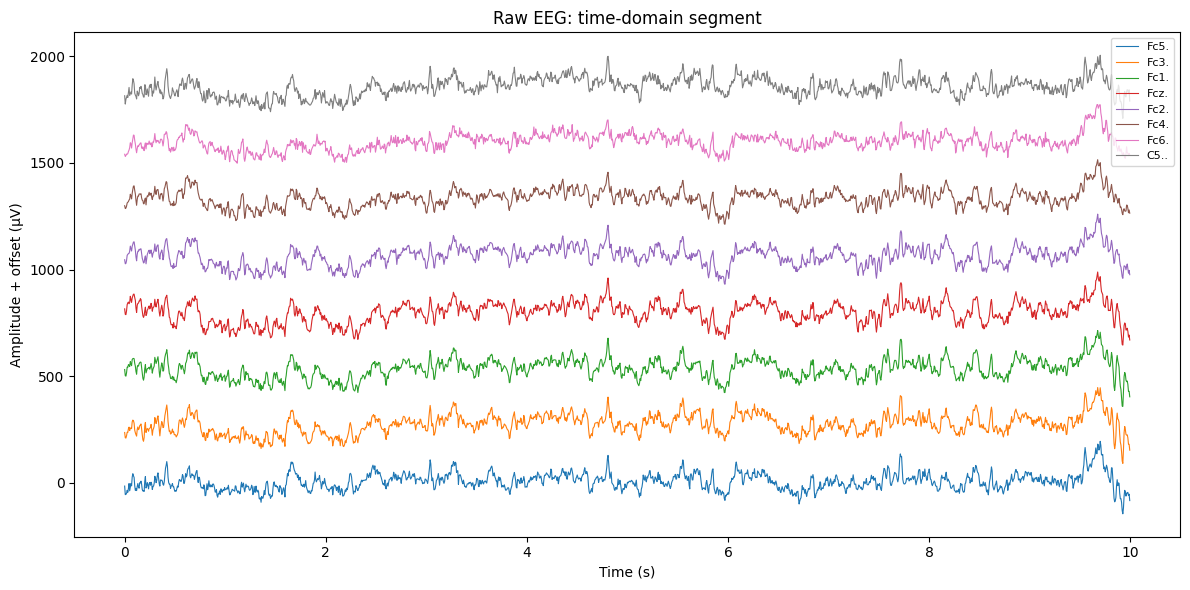

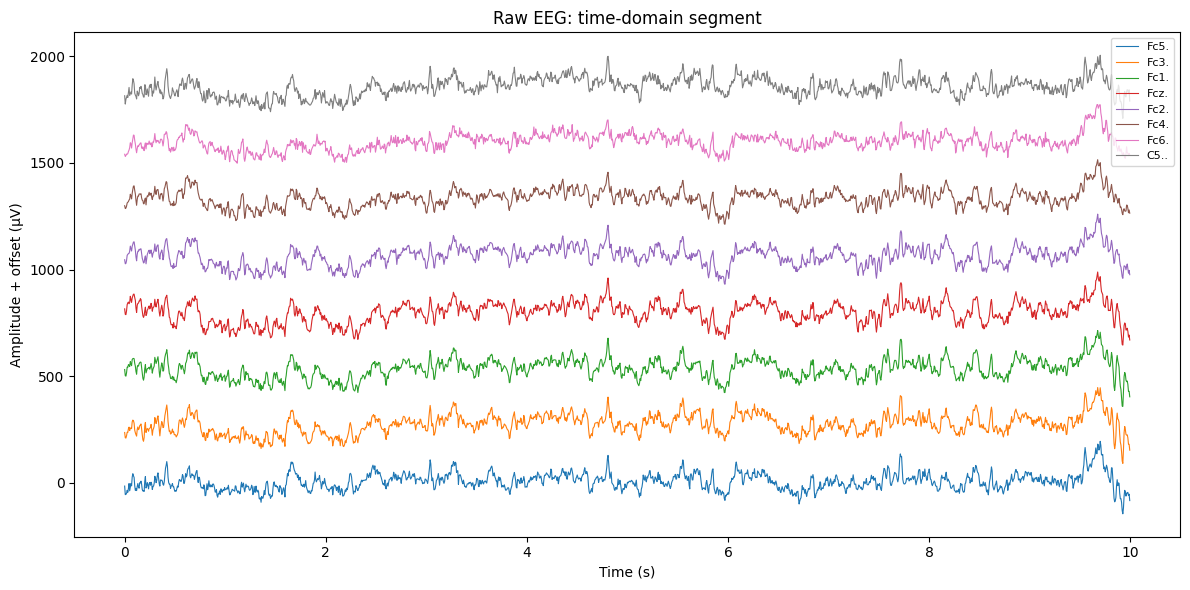

In [42]:
plot_raw_segment(
    raw,
    OUTPUT_DIR,
    title="Raw EEG: time-domain segment",
    filename="01_raw_time_domain.png",
    duration=10.0,
)

## 7. Inspect Raw EEG in Frequency Domain / PSD

PSD means **Power Spectral Density**. It shows how much signal power exists at each frequency.

This helps detect frequency-specific noise such as 50 Hz power-line noise.

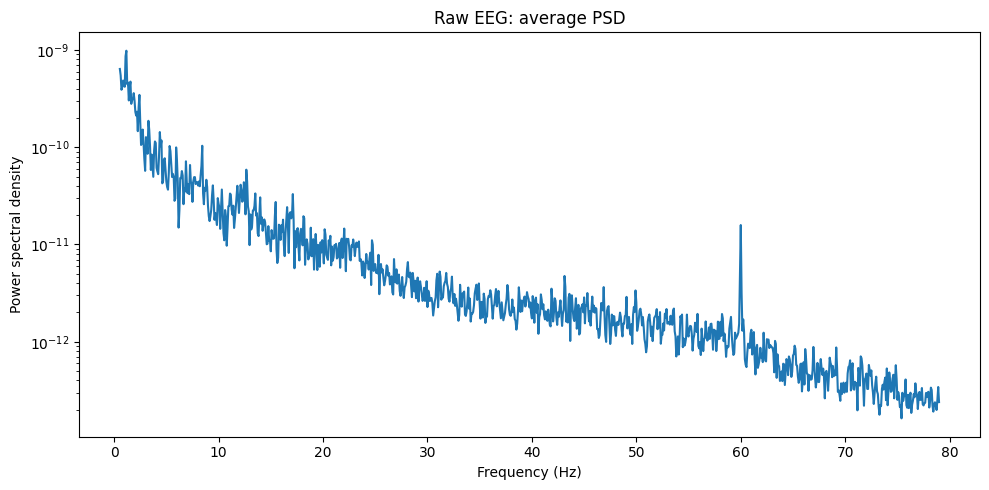

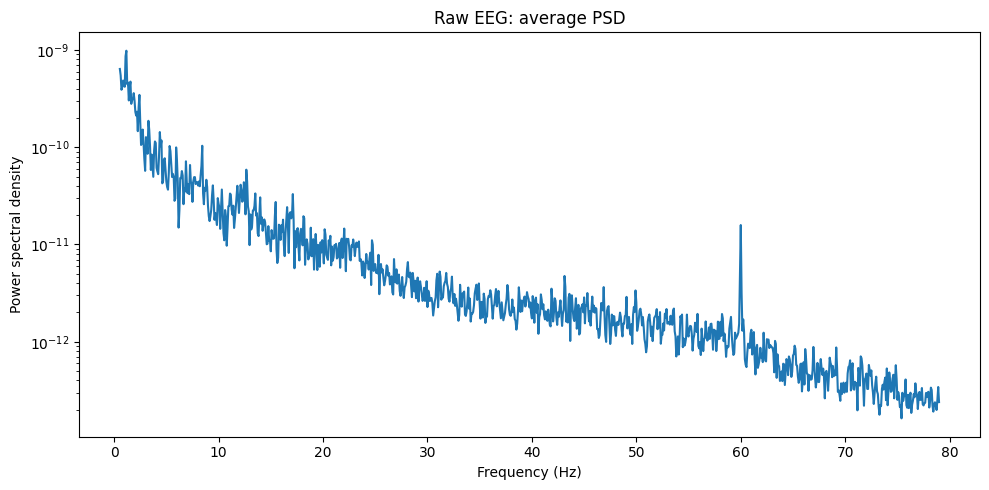

In [43]:
plot_psd(
    raw,
    OUTPUT_DIR,
    title="Raw EEG: average PSD",
    filename="02_raw_psd.png",
    fmin=0.5,
    fmax=80.0,
)

## 8. Apply Basic Noise-Removal Filters

This step applies:

- **Band-pass filter** from `L_FREQ` to `H_FREQ`
- **Notch filter** at `NOTCH_FREQ`

For example, `1–40 Hz` removes slow drift and high-frequency noise, while `50 Hz notch` targets power-line interference.

In [44]:
cleaned = apply_basic_filters(raw, l_freq=L_FREQ, h_freq=H_FREQ, notch_freq=NOTCH_FREQ)
print("Filtering complete.")

Filtering complete.


## 9. Optional ICA

ICA can be used to identify and remove artifact-related components, especially EOG or ECG components.

For the first run, keep `RUN_ICA = False`. After the basic pipeline works, you can set it to `True` in the configuration cell and rerun the notebook.

In [45]:
ica_report = {"ica_requested": RUN_ICA}

if RUN_ICA:
    cleaned, ica_report = run_optional_ica(cleaned, OUTPUT_DIR)

ica_report

{'ica_requested': False}

## 10. Inspect Cleaned EEG in Time Domain

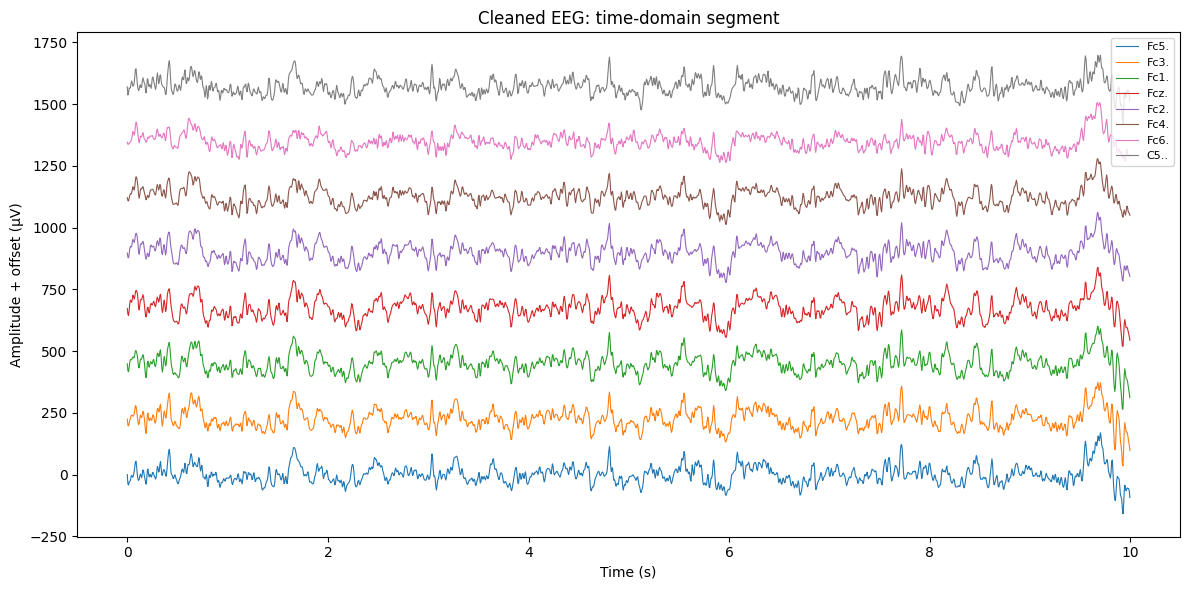

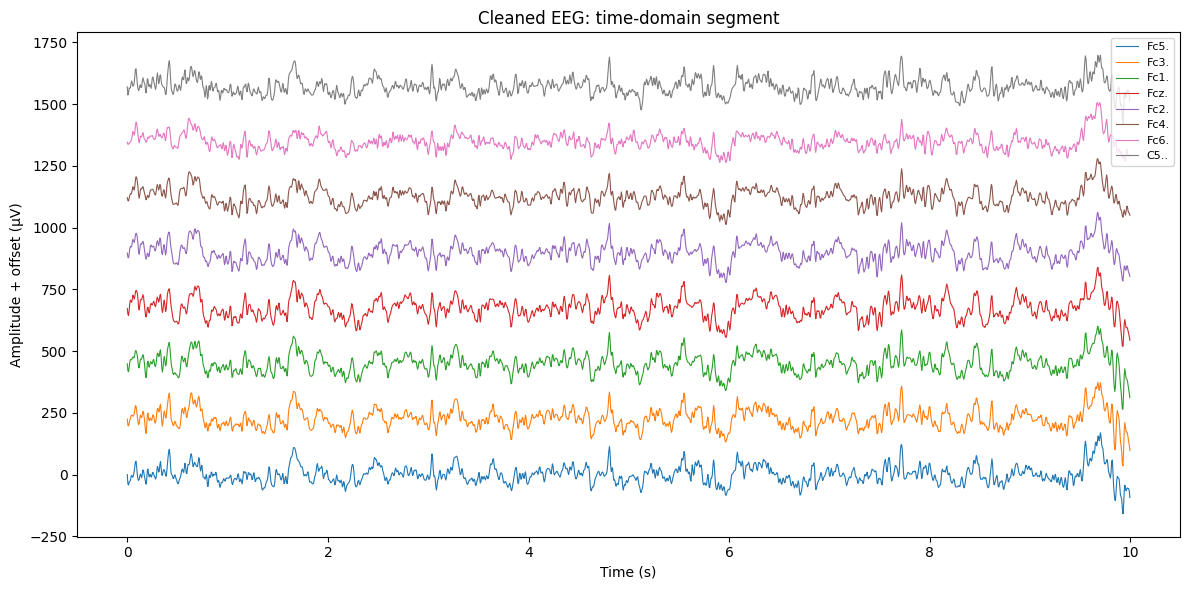

In [46]:
plot_raw_segment(
    cleaned,
    OUTPUT_DIR,
    title="Cleaned EEG: time-domain segment",
    filename="03_cleaned_time_domain.png",
    duration=10.0,
)

## 11. Inspect Cleaned EEG PSD

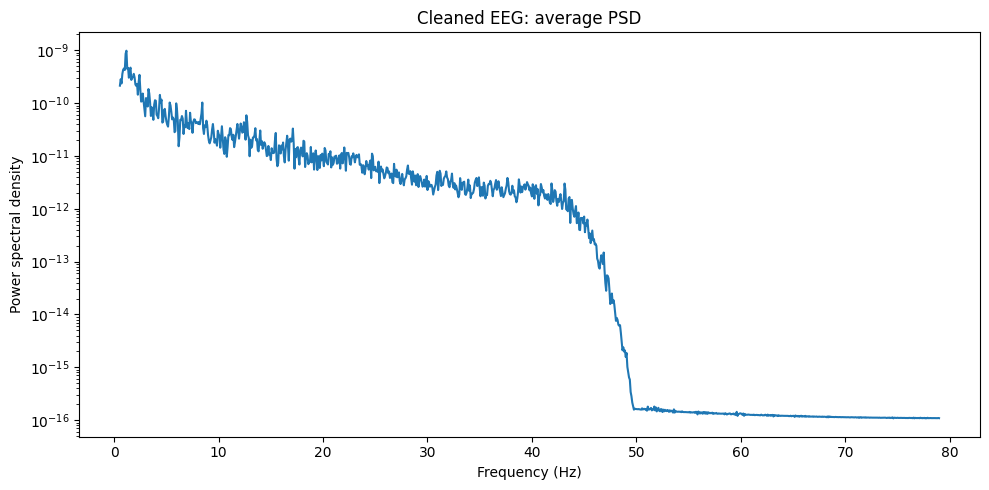

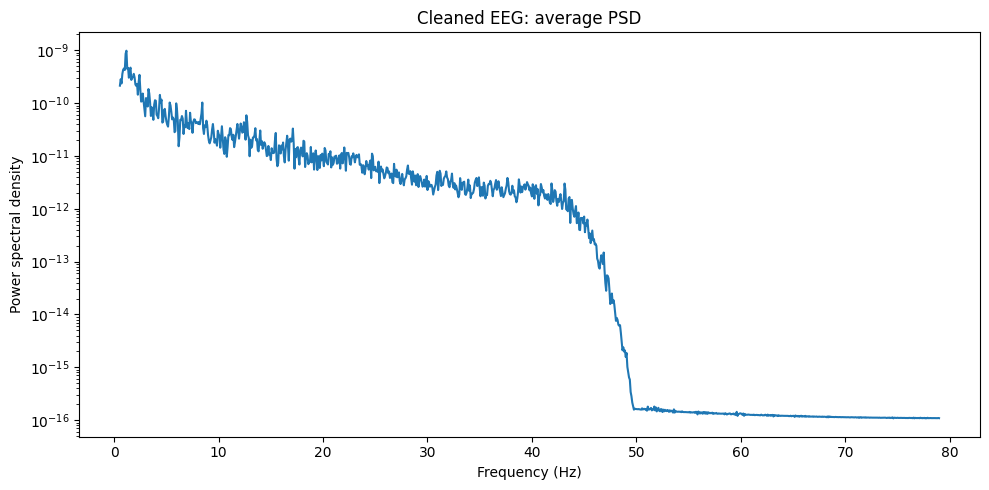

In [47]:
plot_psd(
    cleaned,
    OUTPUT_DIR,
    title="Cleaned EEG: average PSD",
    filename="04_cleaned_psd.png",
    fmin=0.5,
    fmax=80.0,
)

## 12. Compare Raw vs Cleaned PSD

This is the most important output plot for your presentation. It shows whether frequency-specific noise was reduced after preprocessing.

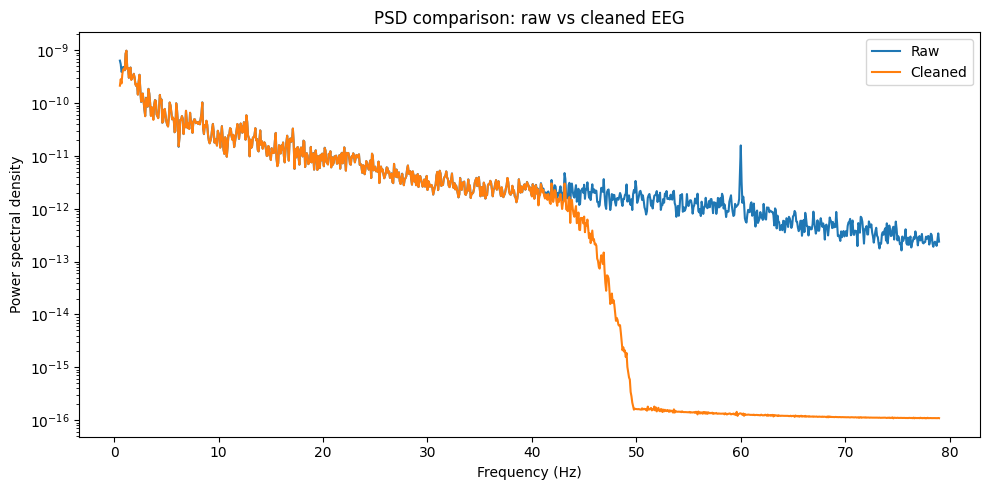

In [48]:
eeg_picks = mne.pick_types(raw_original.info, eeg=True, eog=False, ecg=False, exclude="bads")

if len(eeg_picks) == 0:
    raise RuntimeError("No EEG channels found for PSD comparison.")

fmax = min(80, raw_original.info["sfreq"] / 2 - 1)
psd_raw = raw_original.compute_psd(picks=eeg_picks, fmin=0.5, fmax=fmax, verbose=False)
psd_clean = cleaned.compute_psd(picks=eeg_picks, fmin=0.5, fmax=fmax, verbose=False)

raw_vals, freqs = psd_raw.get_data(return_freqs=True)
clean_vals, freqs2 = psd_clean.get_data(return_freqs=True)

fig = plt.figure(figsize=(10, 5))
plt.semilogy(freqs, raw_vals.mean(axis=0), label="Raw")
plt.semilogy(freqs2, clean_vals.mean(axis=0), label="Cleaned")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD comparison: raw vs cleaned EEG")
plt.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "05_psd_raw_vs_cleaned.png", dpi=200)
plt.show()

## 13. Save Cleaned Data and Pipeline Report

In [49]:
if SAVE_CLEANED:
    cleaned_path = OUTPUT_DIR / "cleaned_eeg_raw.fif"
    cleaned.save(cleaned_path, overwrite=True, verbose=False)
    print("Saved cleaned EEG to:", cleaned_path)

report = {
    "input_file": str(INPUT_FILE),
    "metadata": metadata,
    "pipeline": {
        "bandpass_hz": [L_FREQ, H_FREQ],
        "notch_hz": NOTCH_FREQ,
        "ica": ica_report,
    },
    "outputs": [
        "01_raw_time_domain.png",
        "02_raw_psd.png",
        "03_cleaned_time_domain.png",
        "04_cleaned_psd.png",
        "05_psd_raw_vs_cleaned.png",
    ],
}

with open(OUTPUT_DIR / "pipeline_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Pipeline report saved to:", OUTPUT_DIR / "pipeline_report.json")

Saved cleaned EEG to: results_notebook\cleaned_eeg_raw.fif
Pipeline report saved to: results_notebook\pipeline_report.json
